# Per-Class Threshold Optimization

**Model:** BERTimbau + class weights (`./outputs/`)

Instead of `argmax(p)`, we predict `argmax(p_c / t_c)` where `t_c` is a per-class
threshold tuned on the OOF predictions to maximize balanced accuracy.

This is a zero-cost post-processing step — no retraining required.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from sklearn.metrics import balanced_accuracy_score, classification_report, confusion_matrix

NUM_CLASSES = 7
PROB_COLS   = [f"prob_class_{i}" for i in range(NUM_CLASSES)]
CLASS_NAMES = [f"BI-RADS {i}" for i in range(NUM_CLASSES)]

# ── Paths ─────────────────────────────────────────────────────────────────────
OOF_PATH  = "../outputs_v3_bert_weightbalance_newLoss/oof_predictions.csv"
TEST_PATH = "../outputs_v3_bert_weightbalance_newLoss/test_predictions.csv"

## 1. Load OOF & Test Predictions

In [2]:
oof_df  = pd.read_csv(OOF_PATH)
test_df = pd.read_csv(TEST_PATH)

oof_probs  = oof_df[PROB_COLS].values
oof_labels = oof_df["target"].values

test_probs  = test_df[PROB_COLS].values
test_labels = test_df["target"].values

# Baseline: argmax
oof_baseline  = oof_probs.argmax(axis=1)
test_baseline = test_probs.argmax(axis=1)

print(f"OOF  samples: {len(oof_df)}")
print(f"Test samples: {len(test_df)}")
print(f"\nBaseline (argmax):")
print(f"  OOF  Balanced Accuracy: {balanced_accuracy_score(oof_labels,  oof_baseline):.4f}")
print(f"  Test Balanced Accuracy: {balanced_accuracy_score(test_labels, test_baseline):.4f}")

OOF  samples: 14617
Test samples: 3655

Baseline (argmax):
  OOF  Balanced Accuracy: 0.7113
  Test Balanced Accuracy: 0.7010


## 2. Threshold Optimization

We search for threshold vector **t** ∈ ℝ⁷ such that predicting
`argmax(p_c / t_c)` maximises OOF balanced accuracy.

Thresholds > 1 make a class harder to predict (raise its bar),
thresholds < 1 make it easier.

In [3]:
def predict_with_thresholds(probs, thresholds):
    """Predict class as argmax(p_c / t_c)."""
    adjusted = probs / np.clip(thresholds, 1e-8, None)
    return adjusted.argmax(axis=1)


def neg_balanced_acc(log_thresholds, probs, labels):
    """Objective: negative balanced accuracy (we minimise).
    Optimise in log-space so thresholds stay positive.
    """
    thresholds = np.exp(log_thresholds)
    preds = predict_with_thresholds(probs, thresholds)
    return -balanced_accuracy_score(labels, preds)


# ── Run optimisation ──────────────────────────────────────────────────────────
x0 = np.zeros(NUM_CLASSES)  # log(1) = 0  →  all thresholds start at 1.0

result = minimize(
    neg_balanced_acc,
    x0=x0,
    args=(oof_probs, oof_labels),
    method="Nelder-Mead",
    options={"maxiter": 10_000, "xatol": 1e-5, "fatol": 1e-5},
)

optimal_thresholds = np.exp(result.x)

print("Optimisation result:")
print(f"  Converged: {result.success}  ({result.message})")
print(f"  Iterations: {result.nit}")
print()
print("Optimal thresholds:")
for i, t in enumerate(optimal_thresholds):
    print(f"  BI-RADS {i}: {t:.4f}")

Optimisation result:
  Converged: True  (Optimization terminated successfully.)
  Iterations: 6

Optimal thresholds:
  BI-RADS 0: 1.0000
  BI-RADS 1: 1.0000
  BI-RADS 2: 1.0000
  BI-RADS 3: 1.0000
  BI-RADS 4: 1.0000
  BI-RADS 5: 1.0000
  BI-RADS 6: 1.0000


## 3. OOF Evaluation with Optimised Thresholds

In [4]:
oof_tuned = predict_with_thresholds(oof_probs, optimal_thresholds)

oof_ba_baseline = balanced_accuracy_score(oof_labels, oof_baseline)
oof_ba_tuned    = balanced_accuracy_score(oof_labels, oof_tuned)

print("OOF Results:")
print(f"  Baseline (argmax) Balanced Accuracy: {oof_ba_baseline:.4f}")
print(f"  Tuned  thresholds Balanced Accuracy: {oof_ba_tuned:.4f}")
print(f"  Delta: {oof_ba_tuned - oof_ba_baseline:+.4f}")
print()
print("OOF Classification Report (tuned):")
print(classification_report(oof_labels, oof_tuned, target_names=CLASS_NAMES))

OOF Results:
  Baseline (argmax) Balanced Accuracy: 0.7113
  Tuned  thresholds Balanced Accuracy: 0.7113
  Delta: +0.0000

OOF Classification Report (tuned):
              precision    recall  f1-score   support

   BI-RADS 0       0.75      0.84      0.79       488
   BI-RADS 1       0.88      0.99      0.93       555
   BI-RADS 2       0.99      0.95      0.97     12774
   BI-RADS 3       0.42      0.75      0.54       570
   BI-RADS 4       0.59      0.64      0.61       171
   BI-RADS 5       0.42      0.35      0.38        23
   BI-RADS 6       0.53      0.47      0.50        36

    accuracy                           0.93     14617
   macro avg       0.65      0.71      0.67     14617
weighted avg       0.95      0.93      0.94     14617



## 4. Test Set Evaluation

In [5]:
test_tuned = predict_with_thresholds(test_probs, optimal_thresholds)

test_ba_baseline = balanced_accuracy_score(test_labels, test_baseline)
test_ba_tuned    = balanced_accuracy_score(test_labels, test_tuned)

print("Test Results:")
print(f"  Baseline (argmax) Balanced Accuracy: {test_ba_baseline:.4f}")
print(f"  Tuned  thresholds Balanced Accuracy: {test_ba_tuned:.4f}")
print(f"  Delta: {test_ba_tuned - test_ba_baseline:+.4f}")
print()
print("Test Classification Report (tuned):")
print(classification_report(test_labels, test_tuned, target_names=CLASS_NAMES))

Test Results:
  Baseline (argmax) Balanced Accuracy: 0.7010
  Tuned  thresholds Balanced Accuracy: 0.7010
  Delta: +0.0000

Test Classification Report (tuned):
              precision    recall  f1-score   support

   BI-RADS 0       0.80      0.82      0.81       122
   BI-RADS 1       0.84      0.98      0.91       138
   BI-RADS 2       0.99      0.95      0.97      3194
   BI-RADS 3       0.44      0.77      0.56       143
   BI-RADS 4       0.69      0.72      0.70        43
   BI-RADS 5       0.00      0.00      0.00         6
   BI-RADS 6       0.86      0.67      0.75         9

    accuracy                           0.94      3655
   macro avg       0.66      0.70      0.67      3655
weighted avg       0.95      0.94      0.94      3655



## 5. Visualisation

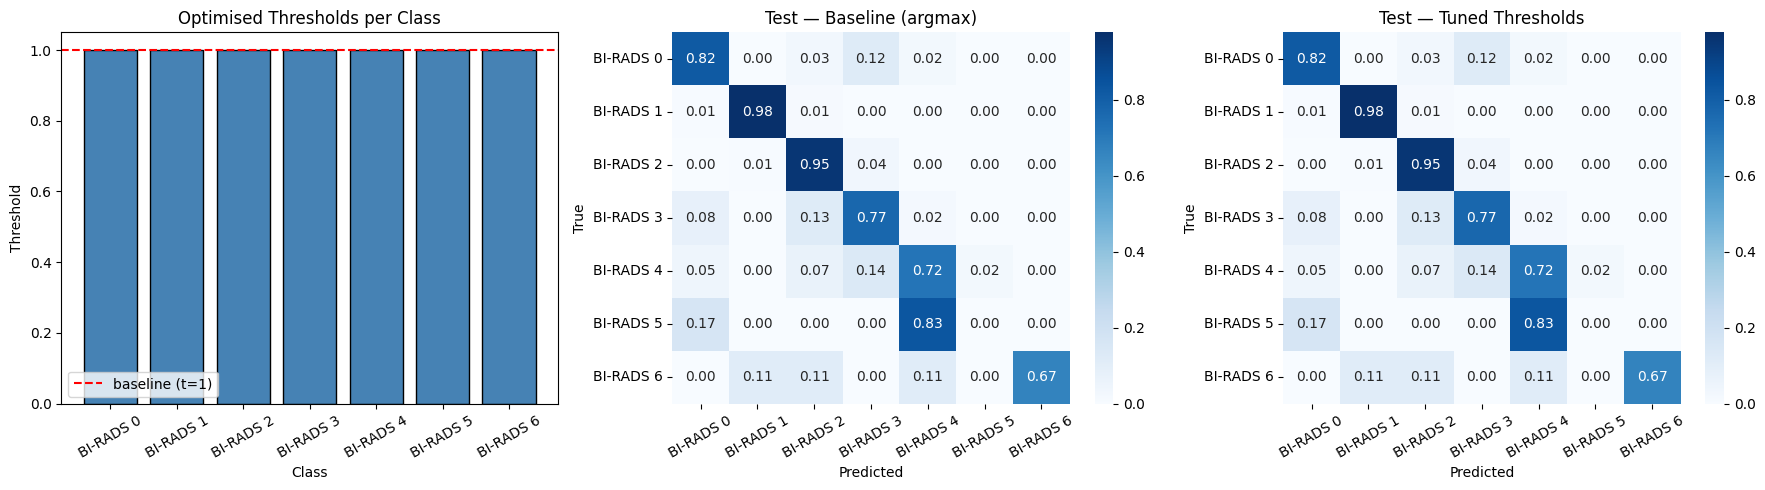

In [6]:
# ── Threshold values ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(CLASS_NAMES, optimal_thresholds, color="steelblue", edgecolor="black")
axes[0].axhline(1.0, color="red", linestyle="--", label="baseline (t=1)")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Threshold")
axes[0].set_title("Optimised Thresholds per Class")
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend()

# ── Confusion matrices ────────────────────────────────────────────────────────
for ax, preds, title in [
    (axes[1], test_baseline, "Test — Baseline (argmax)"),
    (axes[2], test_tuned,    "Test — Tuned Thresholds"),
]:
    cm = confusion_matrix(test_labels, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## 6. Save Results

In [8]:
# Save optimal thresholds
thresh_df = pd.DataFrame({"class": CLASS_NAMES, "threshold": optimal_thresholds})
thresh_df.to_csv("./outputs_threshold_optimization/optimal_thresholds.csv", index=False)
print("Saved optimal_thresholds.csv")

# Save tuned test predictions
out = test_df[["ID", "target"]].copy()
out["predicted_baseline"] = test_baseline
out["predicted_tuned"]    = test_tuned
out["correct_baseline"]   = out["target"] == out["predicted_baseline"]
out["correct_tuned"]      = out["target"] == out["predicted_tuned"]
out.to_csv("./outputs/test_predictions_tuned.csv", index=False)
print("Saved test_predictions_tuned.csv")

print(f"\nFinal summary:")
print(f"  OOF  Baseline: {oof_ba_baseline:.4f}  →  Tuned: {oof_ba_tuned:.4f}  ({oof_ba_tuned - oof_ba_baseline:+.4f})")
print(f"  Test Baseline: {test_ba_baseline:.4f}  →  Tuned: {test_ba_tuned:.4f}  ({test_ba_tuned - test_ba_baseline:+.4f})")

Saved optimal_thresholds.csv
Saved test_predictions_tuned.csv

Final summary:
  OOF  Baseline: 0.7113  →  Tuned: 0.7113  (+0.0000)
  Test Baseline: 0.7010  →  Tuned: 0.7010  (+0.0000)
